# **Logistic regression finding best model**

1. Setting up libraries

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2. Setting up data to get X and Y

In [2]:
parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

# cleaning and processing data to get X and Y
df = pd.read_parquet(parquet_path)
df = df.dropna()
df['target'] = (df['conflict_count'] >= 1).astype(int)
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

3. Splitting scaling data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Rebalancing and getting best model according to set of possible $\lambda$ and $\alpha$

In [5]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Base model
base_model = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    max_iter=1000,
    random_state=42
)

# Grid of hyperparameters
param_grid = {
    'C': np.logspace(-3, 1, 5),            # [0.001, 0.01, 0.1, 1, 10]
    'l1_ratio': np.linspace(0, 1, 5)       # [0.0, 0.25, 0.5, 0.75, 1.0]
}

# Grid search with recall_weighted
grid = GridSearchCV(
    base_model,
    param_grid,
    scoring='recall_weighted',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid.fit(X_train_smote, y_train_smote)



Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, penalty='elasticnet',
                                          random_state=42, solver='saga'),
             n_jobs=-1,
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01]),
                         'l1_ratio': array([0.  , 0.25, 0.5 , 0.75, 1.  ])},
             scoring='recall_weighted', verbose=1)

5. Evaluating and getting confusion matrix

In [6]:
# Evaluate
best_model = grid.best_estimator_
y_pred_smote = best_model.predict(X_test_scaled)

labels = best_model.classes_

# Confusion matrix with labels
conf_matrix = confusion_matrix(y_test, y_pred_smote)
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)


6. Printing results

In [7]:
print("\n--- Tuned SMOTE + ElasticNet Model ---")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best l1_ratio: {grid.best_params_['l1_ratio']}")
print(f"Best weighted recall (CV): {grid.best_score_:.4f}")

print("-----------------------------")

print(f"\nTest Accuracy: {best_model.score(X_test_scaled, y_test):.4f}")
print(f"Test Recall (weighted): {recall_score(y_test, y_pred_smote, average='weighted'):.4f}")
print("\nConfusion Matrix:")
display(conf_df.style.background_gradient(cmap='Blues'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


--- Tuned SMOTE + ElasticNet Model ---
Best C: 10.0
Best l1_ratio: 0.0
Best weighted recall (CV): 0.8176
-----------------------------

Test Accuracy: 0.8524
Test Recall (weighted): 0.8524

Confusion Matrix:


,0,1
0,5383,868
1,136,416



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      6251
           1       0.32      0.75      0.45       552

    accuracy                           0.85      6803
   macro avg       0.65      0.81      0.68      6803
weighted avg       0.92      0.85      0.88      6803



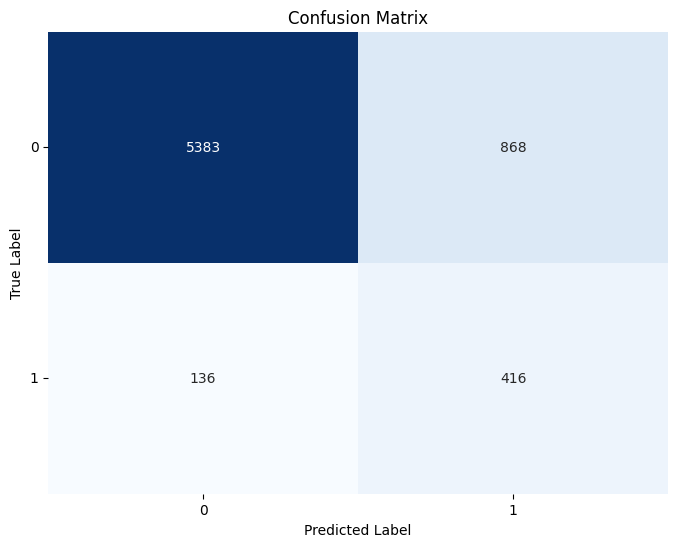

In [9]:
# plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()